# EDA analiza znacajki nakon FFT-informiranog filtriranja

Struktura notebooka:
1. Uvoz i osnovne postavke
2. Uniformno pretprocesiranje (notch filter za mrezni hum + high-pass)
3. Ekstrakcija prosirenog seta znacajki (energy ratio po pojasu, spectral slope, peak frequency, bandwidth low-band, flux, flatness, harmonic ratio, prvih 5 MFCC mean+std)
4. EDA: PDF/KDE, boxplot, korelacija, F-test/MI, PCA
5. Usporedba prosjecnih spektrograma po klasi
6. Multivarijatni klasifikator (RandomForest) - stvarni test jesu li znacajke dovoljno dobre

In [12]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from IPython.display import Audio
import os
from scipy.io.wavfile import write

base_path = '../../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

## 1. Uniformno pretprocesiranje

Iz FFT grafa (0-200Hz) vidljiv je ostar, uzak siljak tocno na 100Hz (i naznake na 150/200Hz).
To odgovara harmonicima mrezne frekvencije, vjerojatno nesto povezano uz opremu za snimanje, ne zvuk
vozila. Uklanjamo ga notch filterima prije bilo kakve ekstrakcije znacajki, jer bi inace npr.
`peak_frequency` mogao "pronaci" hum umjesto stvarnog vrha spektra vozila.

Dodajemo i blagi high-pass (oko15Hz) da uklonimo DC/handling sum - FFT graf pokazuje da je
energija svih klasa ispod oko 15-20Hz zanemariva, pa ovo ne dira signal koji nas zanima.

In [13]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima. Q=30 znaci vrlo uzak filter - makne samo usku vrpcu oko svake
    frekvencije, ne dira okolni spektar."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje nam ne trebaju, koje mogu biti samo sum"""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y


def bandpass_filter(y, sr, low, high, order=4):
    """Ako ce trebat...Opcenita bandpass funkcija, koristiti samo kao primjer za cuttanje da vidimo di se nalaze frekvencije, ne stavljati na 
    sve unisono prije modela"""
    sos = signal.butter(order, [low, high], btype='bandpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)

### Provjera filtera na jednom primjeru

Prije nego primijenimo filter na cijeli dataset, pogledat cemo ucinak na jednom primjeru,
usporedba spektra prije/poslije notch filtera treba pokazati da siljak na 100Hz nestane,
a ostatak spektra ostaje manje-vise netaknut.

## 2. Ekstrakcija znacajki

**Finalni set znacajki** :

| Značajka | Što hvata | Zašto je korisna | Kategorija značajke |
|---|---|---|---|
| `rms` | prosječnu energiju signala (root mean square) | razlikuje tihe i glasne izvore; npr. kamioni imaju veći RMS od bicikla | vremenska |
| `zcr` | broj prolazaka signala kroz nulu | visoke vrijednosti ukazuju na šum ili visoke frekvencije (npr. šum vjetra) | vremenska |
| `spectral_centroid` | “centar mase” spektra | pokazuje dominiraju li niske (kamioni) ili visoke frekvencije (bicikl, šum) | spektralna |
| `spectral_bandwidth` | širinu spektra oko centroida | razlikuje tonalne (motor, malen bandwidth) od šumovitih (vjetar) signala | spektralna |
| `spectral_rolloff` | frekvenciju ispod koje je npr. 95% energije | govori koliko je signal “svijetao” (više visokih frekvencija) | spektralna |
| `low_band_energy` | energiju u niskom frekvencijskom pojasu | teška vozila imaju više energije u niskim frekvencijama | spektralna |
| `mid_band_energy` | energiju u srednjem pojasu | korisno za razlikovanje različitih tipova motora i okoline | spektralna |
| `high_band_energy` | energiju u visokom pojasu | šum, trenje i bicikli imaju više energije u ovom području | spektralna |
| `spectral_slope` | nagib spektra (pad energije s frekvencijom) | strm pad znači dominaciju niskih frekvencija | spektralna |
| `bandwidth_low_band` | širinu spektra unutar niskog pojasa | razlikuje stabilne tonove (motor) od “rumble” šuma | spektralna |
| `spectral_flatness` | odnos tonalnosti i šuma | nizak = tonalno (motor), visok = šumovito (vjetar) | spektralna |
| `flux_mean` | prosječnu promjenu spektra kroz vrijeme | detektira dinamiku (npr. prolazak vozila) | vremensko-spektralna |
| `flux_std` | varijabilnost promjene spektra | razlikuje stabilne od promjenjivih izvora zvuka | vremensko-spektralna |
| `harmonic_ratio` | omjer harmonijske i šumovite komponente | motori imaju izražene harmonike, šum nema | vremensko-spektralna |
| `mfcc_0..4_mean` | prosjek niskih MFCC koeficijenata | opisuje globalni oblik spektra (najvažnije informacije) | vremensko-spektralna |
| `mfcc_0..4_std` | varijabilnost MFCC koeficijenata | hvata promjene kroz vrijeme (npr. ubrzavanje vozila) | vremensko-spektralna |
| `mfcc_0` | log-energiju signala | sličan RMS-u, ali robusniji na varijacije | vremensko-spektralna |
| `mfcc_1` | nagib spektralne envelope | razlikuje bass-heavy i high-frequency izvore | vremensko-spektralna |
| `mfcc_2` | zakrivljenost envelope | pokazuje koncentraciju energije u spektru | vremensko-spektralna |
| `mfcc_3` | finu strukturu spektra | hvata harmonike, rezonancije i detalje motora | vremensko-spektralna |
| `mfcc_4` | još finiju strukturu spektralne envelope | hvata suptilne razlike u raspodjeli energije i harmonijskoj strukturi | vremensko-spektralna |

Nize MFCC koeficijente (0-4) biramo namjerno umjesto svih 13 - u prethodnoj analizi (F-test)
upravo su nizi koeficijenti (mfcc_1, mfcc_3) bili najinformativniji, a visi uglavnom dodaju sum
bez puno diskriminativne snage za ovaj problem.

In [14]:
LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))  # ublaži edge efekte
    y_win = y * window
    
    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2
    
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope



def bandwidth_low_band(freqs, psd):
    """Spektralna sirina (tezinski std frekvencije) racunata SAMO unutar
    niskog pojasa - hvata je li niskofrekventna energija uska (jak,
    uzak ton motora) ili siroka (rasprseni rumble)."""
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

In [16]:
CACHE_PATH = '../../data/features_cache/znacajke_cache.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene - samo ucitamo gotov DataFrame 
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []

    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 10 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]

    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi (provjera balansa):")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

df.head()

Znacajke ucitane iz cachea: ../../data/features_cache/znacajke_cache.pkl (11391 uzoraka)

Broj uzoraka po klasi (provjera balansa):
label
CAR      9348
HEAVY    1190
MC        519
BIC       334
Name: count, dtype: int64


,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,low_band_energy,mid_band_energy,high_band_energy,spectral_slope,bandwidth_low_band,...,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,label
0,0.065307,0.019609,1826.503815,3078.726276,3590.425532,0.885687,0.101071,0.013052,-1.867504,45.903706,...,10.003626,178.775146,8.686232,-21.621541,5.821289,36.673271,4.580609,-1.047381,4.811483,BIC
1,0.035374,0.015698,2076.097549,4056.747926,4311.128657,0.971927,0.026018,0.001874,-2.311674,32.781818,...,22.649855,156.664657,11.681949,12.578587,7.050431,34.767883,6.372147,6.526522,8.544958,BIC
2,0.023371,0.036772,2588.184819,4263.899547,5891.040559,0.606855,0.378988,0.010833,-2.257224,65.991067,...,19.032952,167.932851,13.178547,2.001518,8.522644,37.542249,6.599697,-10.102805,7.831448,BIC
3,0.015145,0.041662,3539.687221,4993.381655,8676.861702,0.865271,0.112723,0.016721,-1.862074,42.518202,...,28.413603,140.353747,20.136714,-1.482174,10.328294,31.438115,6.909532,-8.179644,7.339408,BIC
4,0.005752,0.153959,4113.331616,4369.290481,9066.073803,0.322573,0.342152,0.329180,-1.000743,84.206649,...,13.254949,133.573605,16.001052,-39.154997,12.569525,36.705386,7.314667,-15.412616,6.875457,BIC


## 3. EDA - PDF (KDE), boxplot, korelacija, F-test/MI, PCA


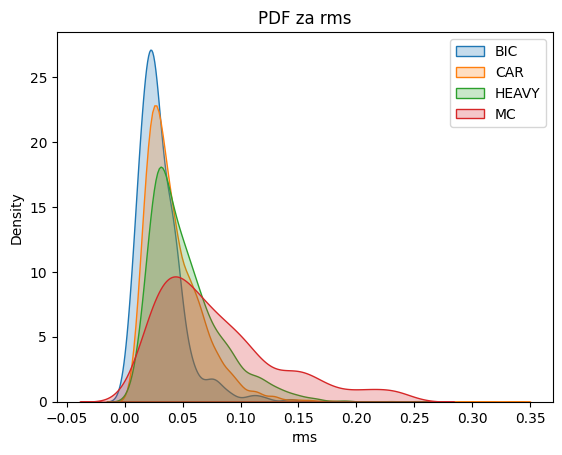

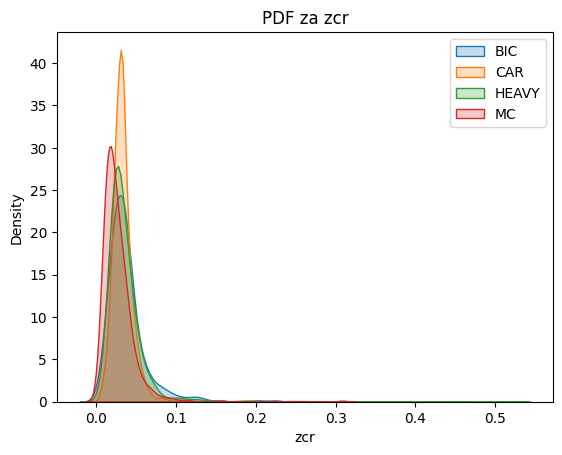

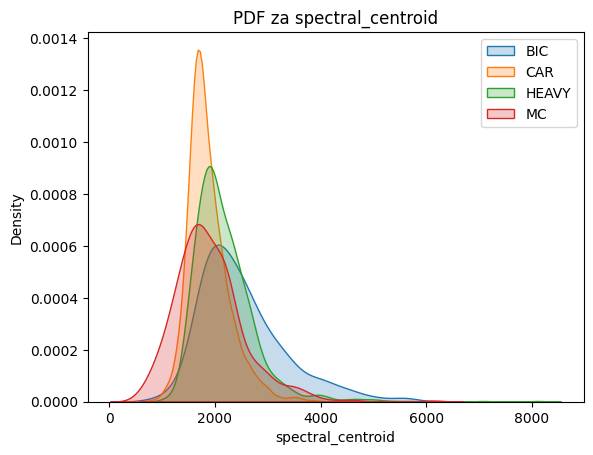

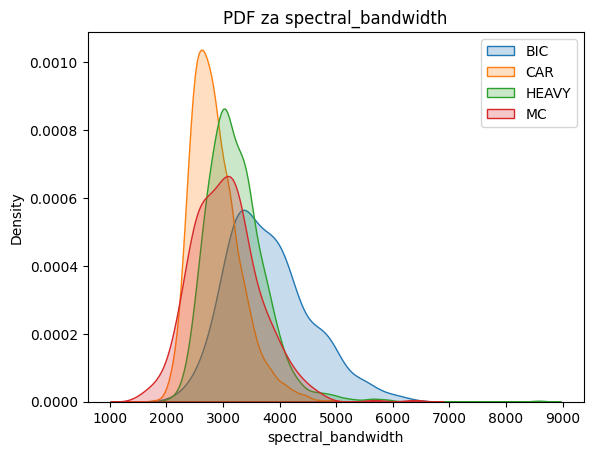

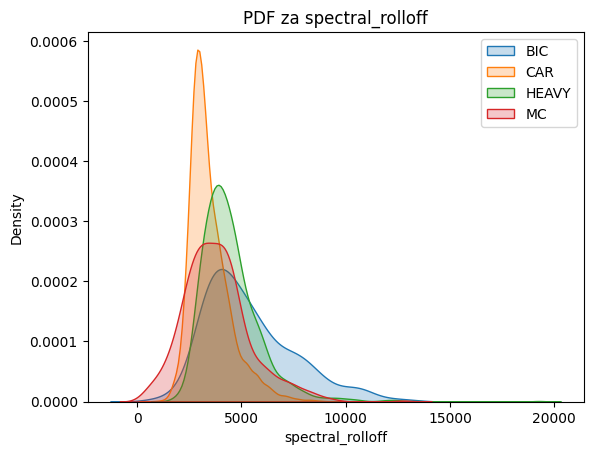

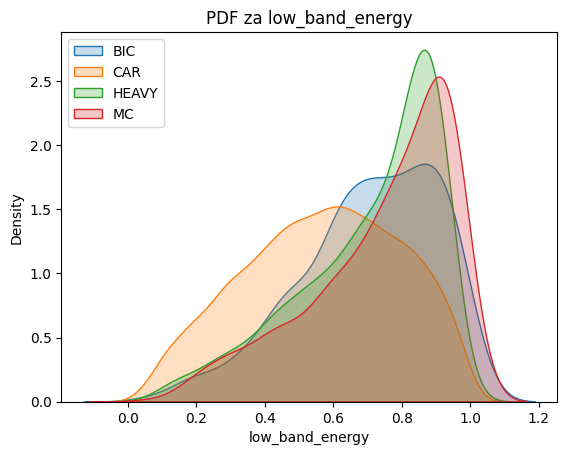

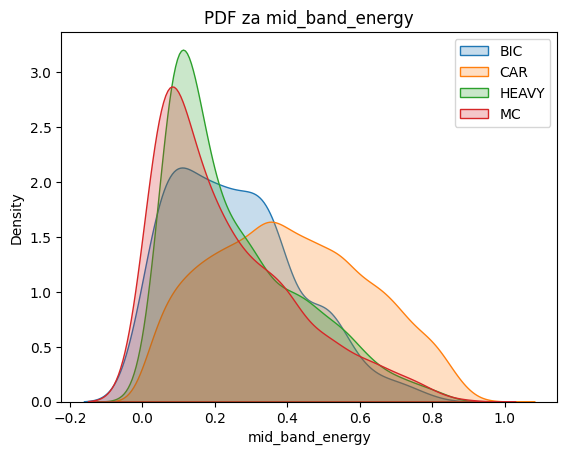

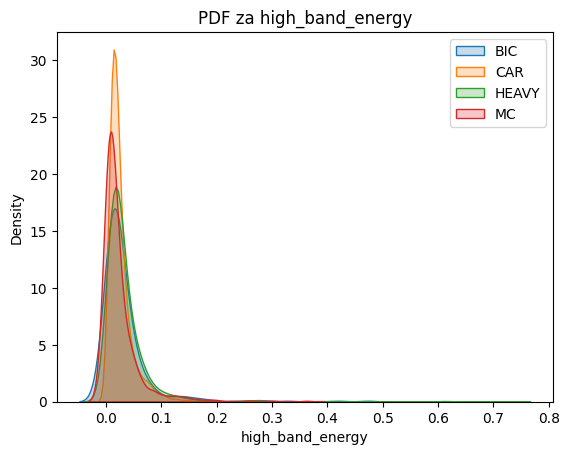

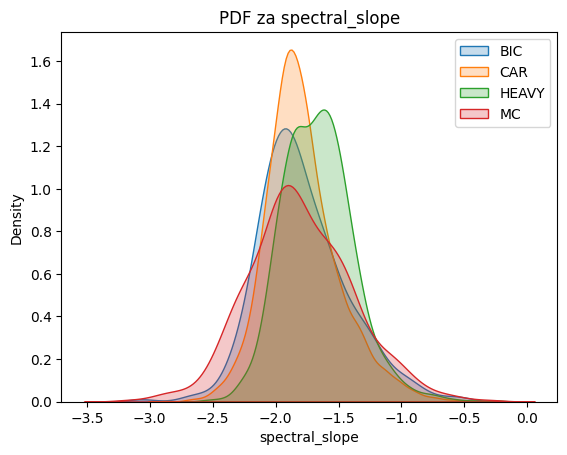

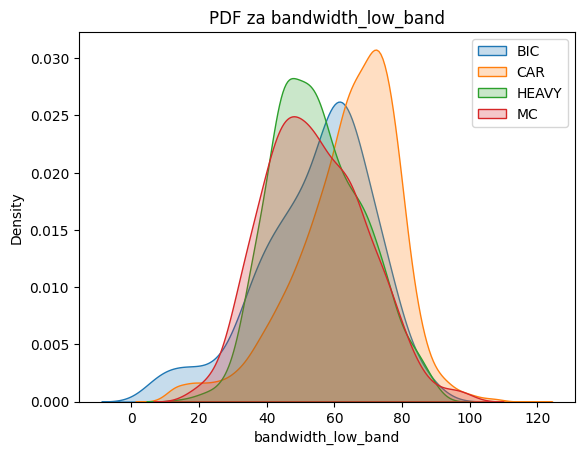

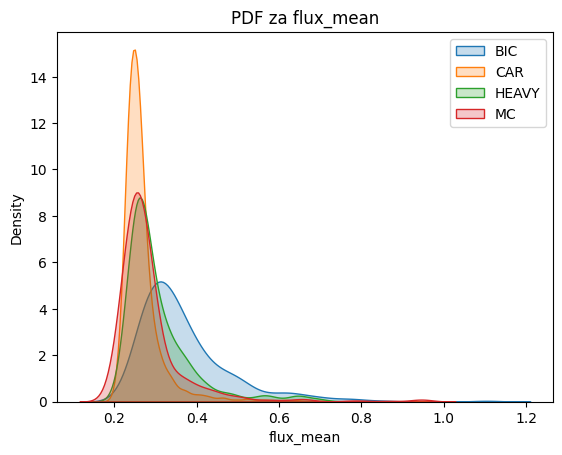

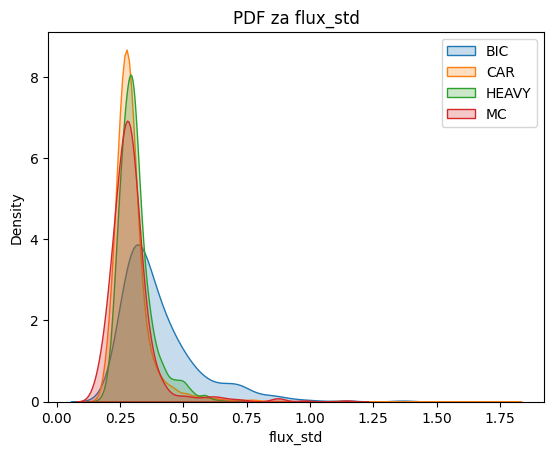

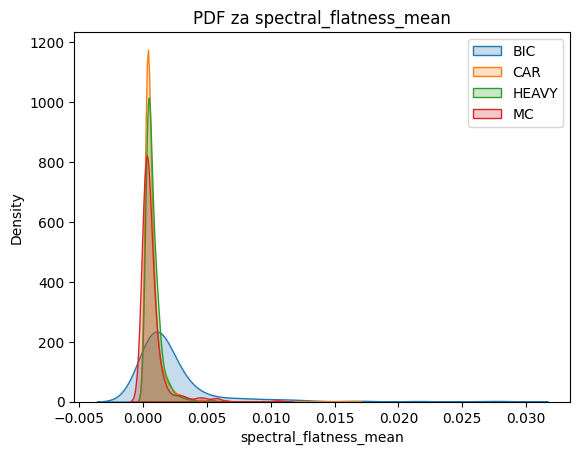

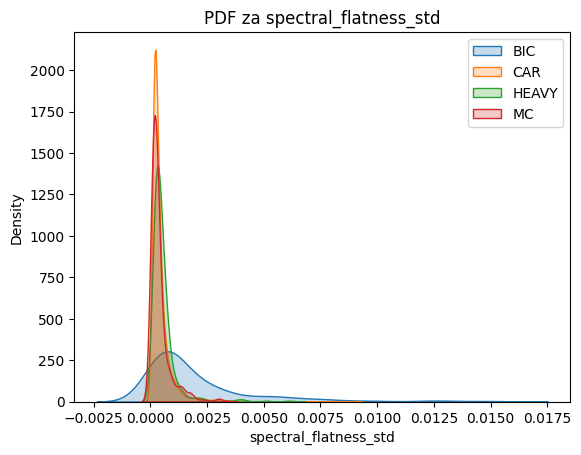

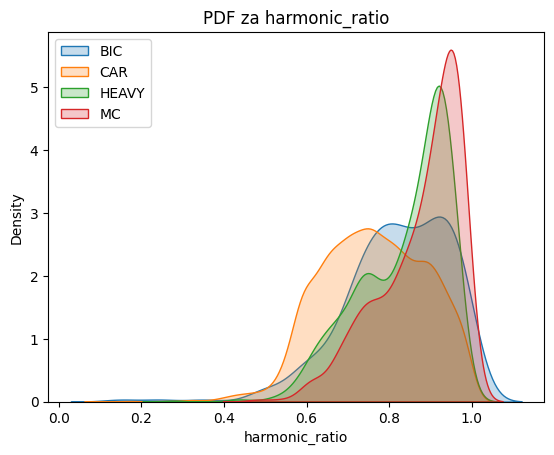

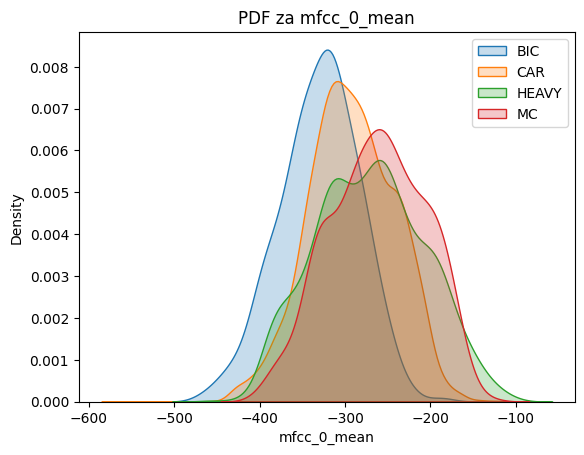

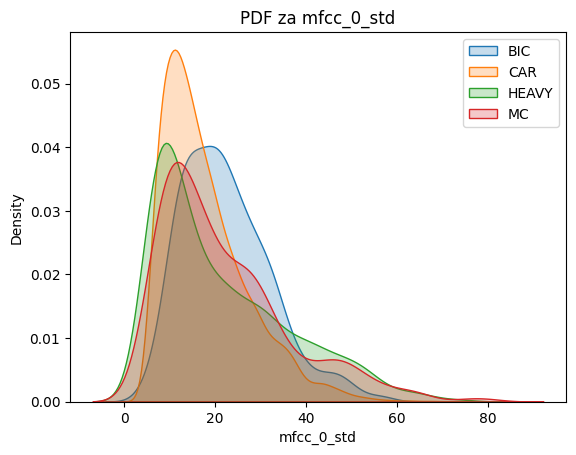

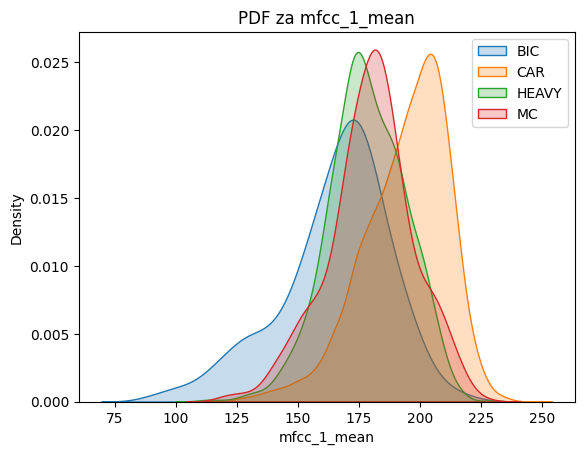

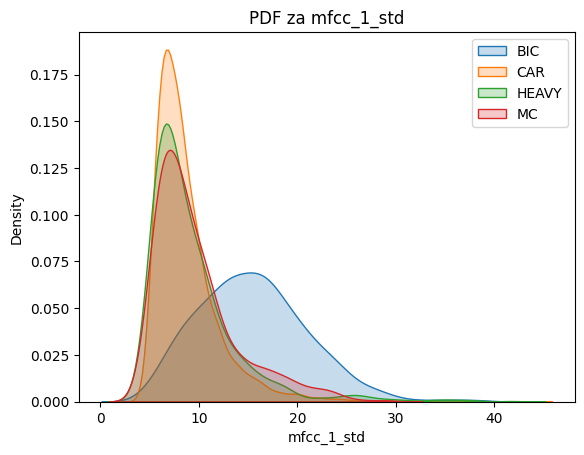

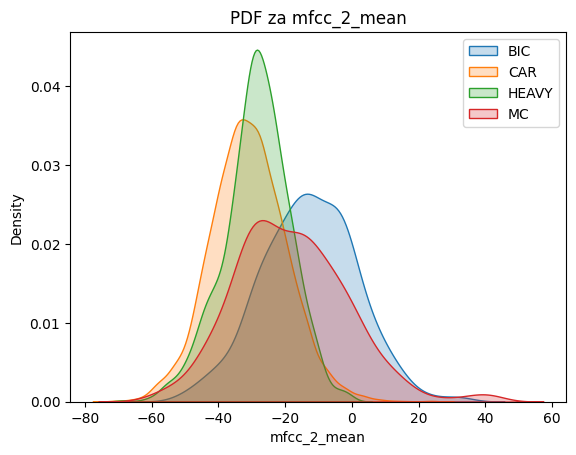

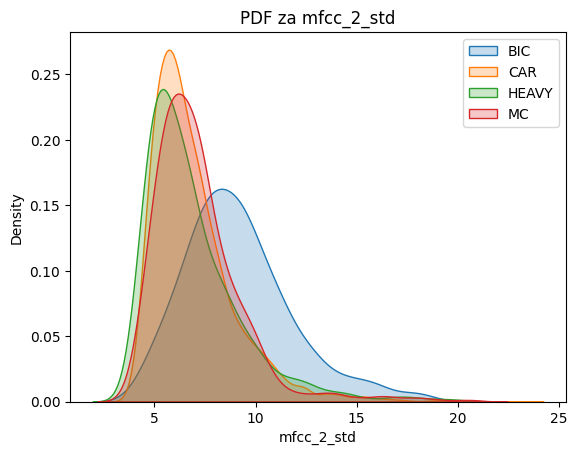

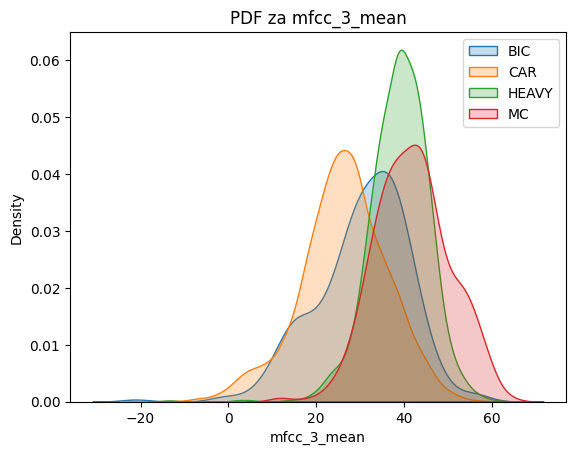

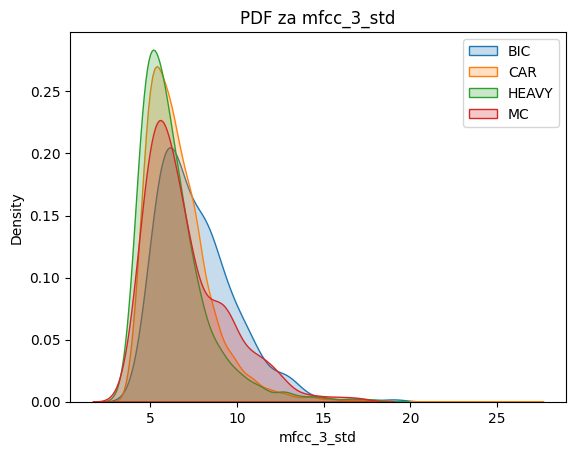

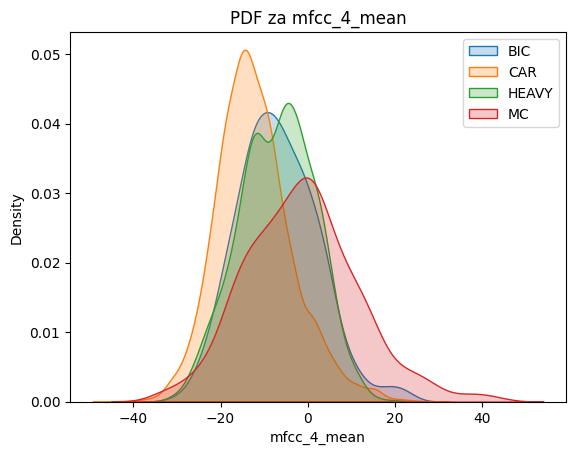

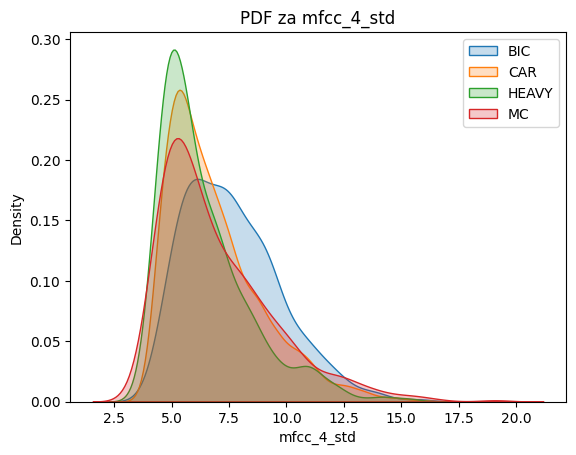

In [ ]:
# Sto graf pokazuje? - Probability Density Function, kako su raspodijeljene vrijednosti znacajki prema klasama.
# Sto zelimo vidjeti? - zelimo da su raspodjele po klasama sto razlicitije, sto znaci da znacajka dobro razlikuje klase. 
# Sto ne zelimo vidjeti? - ne zelimo vidjeti puno preklapanja izmedju klasa, to znaci da znacajka ne razlikuje klase.

features = [c for c in df.columns if c != 'label']

for col in features:
    plt.figure()
    for label in df['label'].unique():
        subset = df[df['label'] == label]
        sns.kdeplot(subset[col], label=label, fill=True)
    plt.title(f'PDF za {col}')
    plt.legend()
    plt.show()

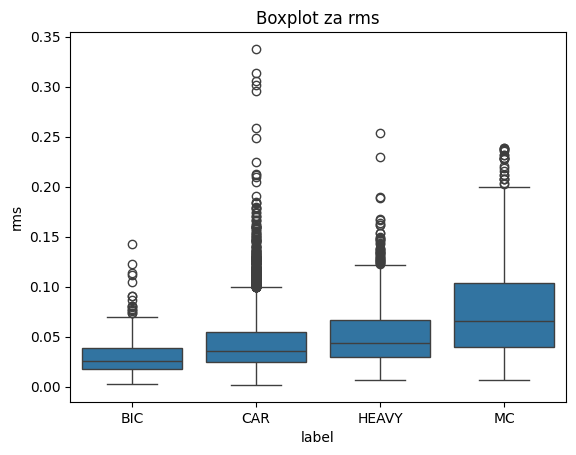

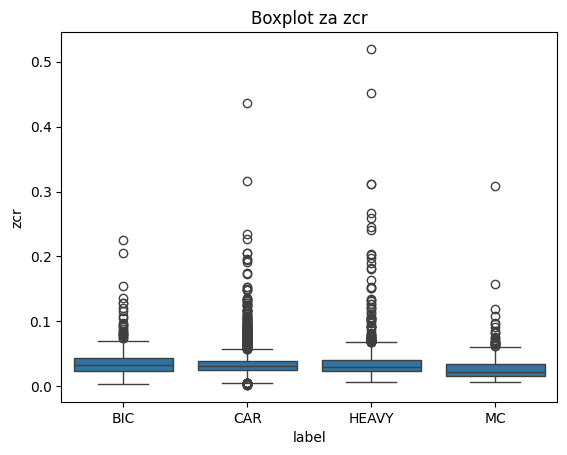

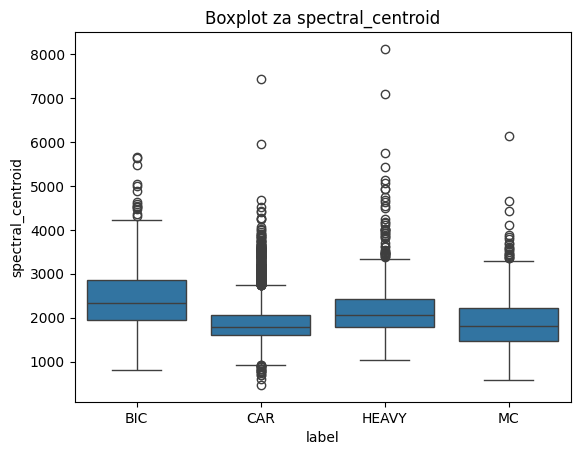

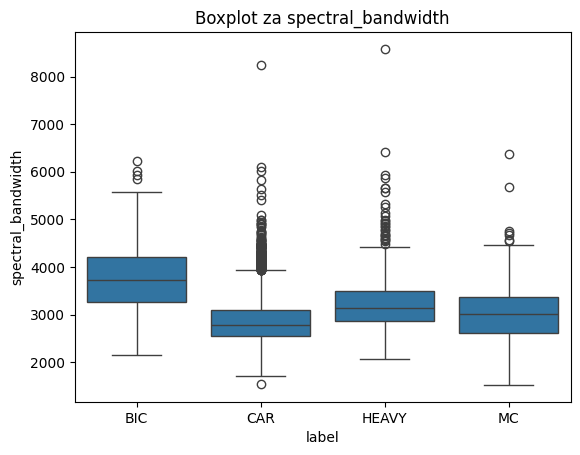

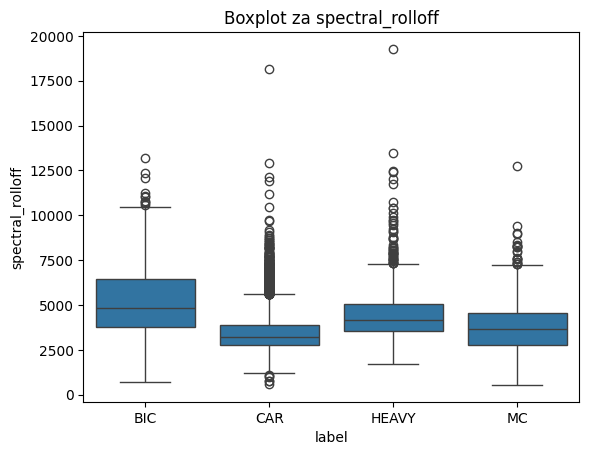

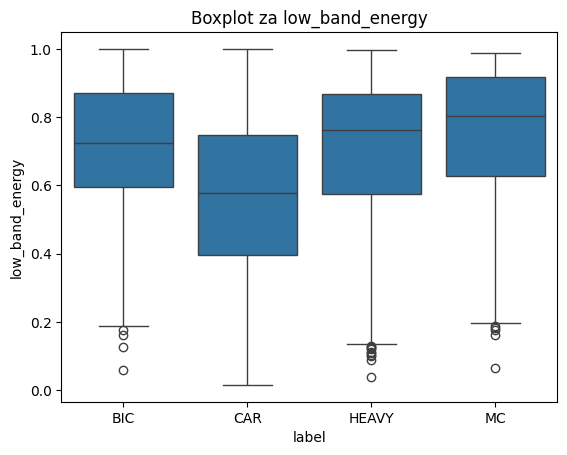

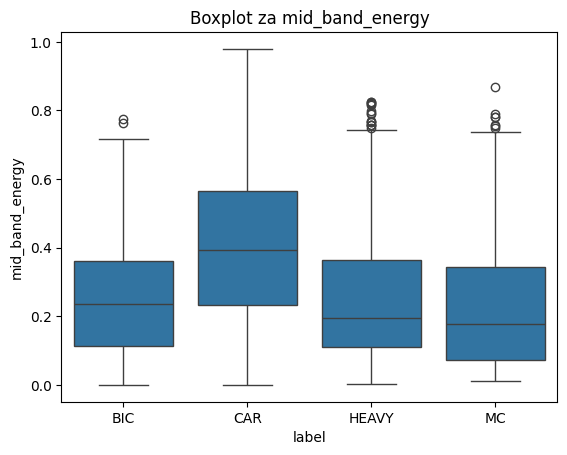

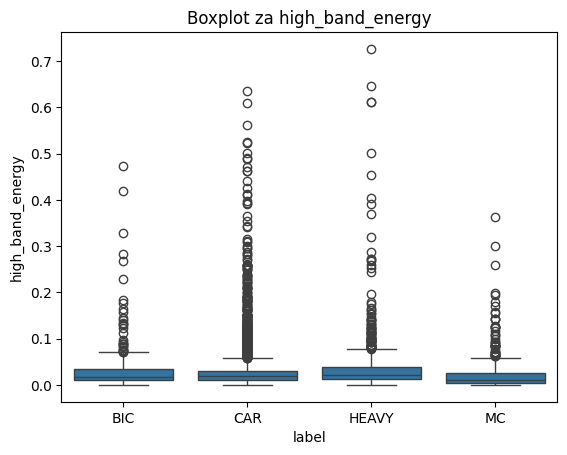

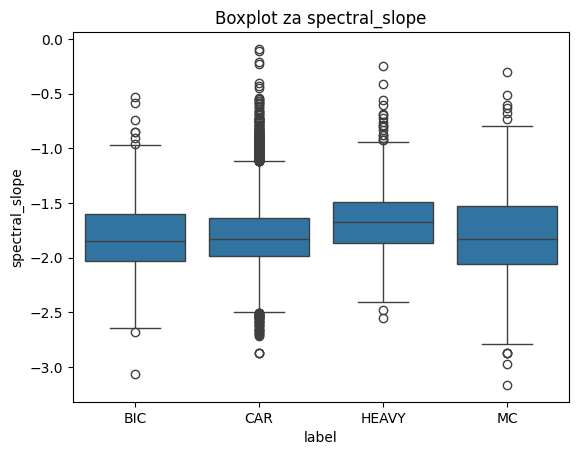

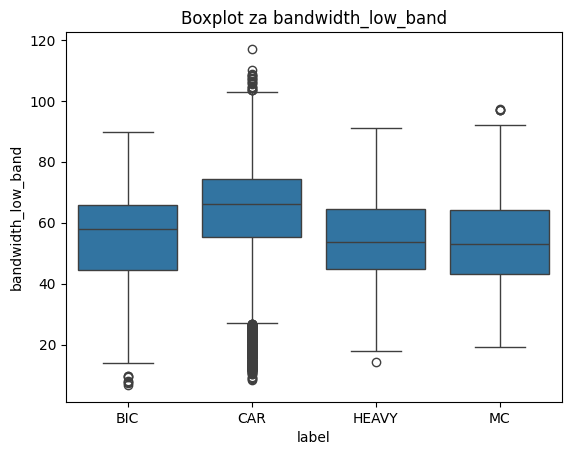

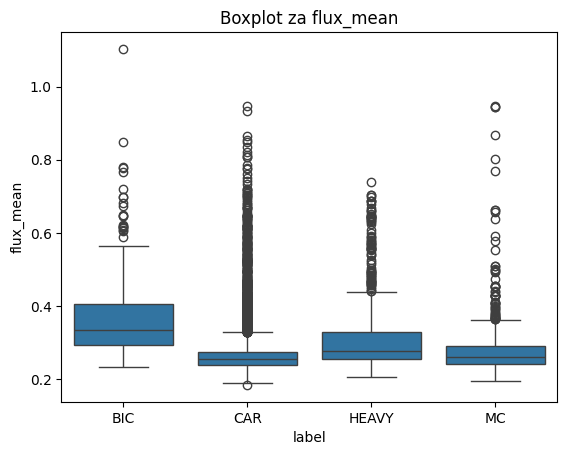

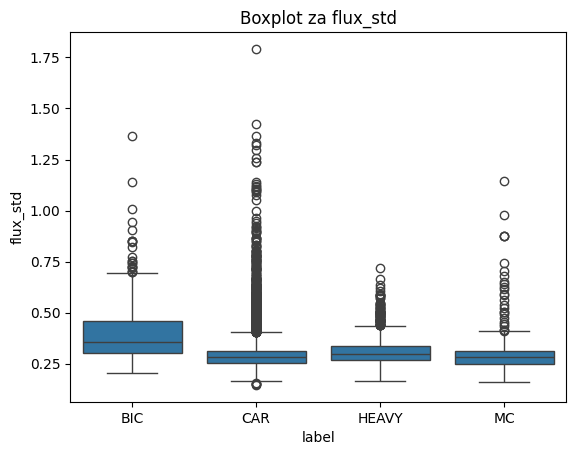

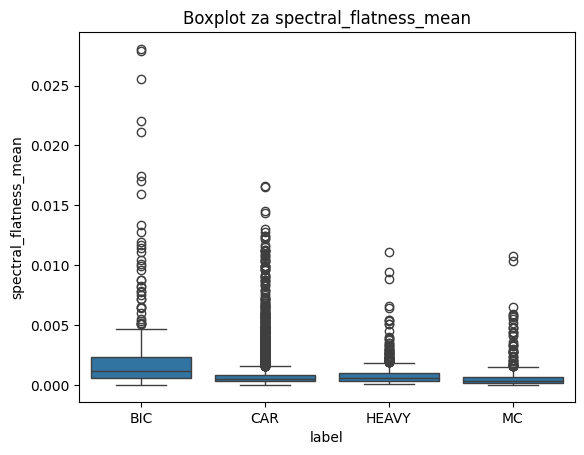

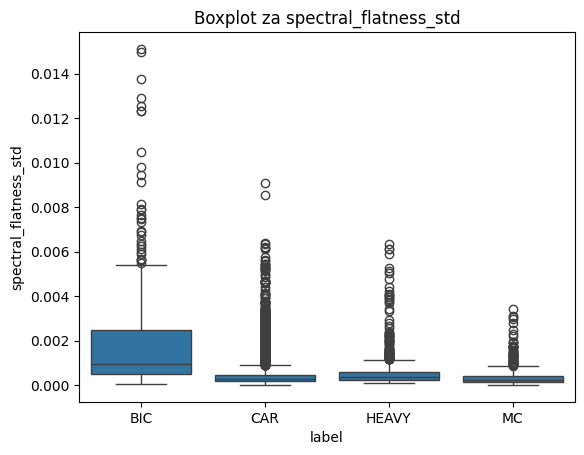

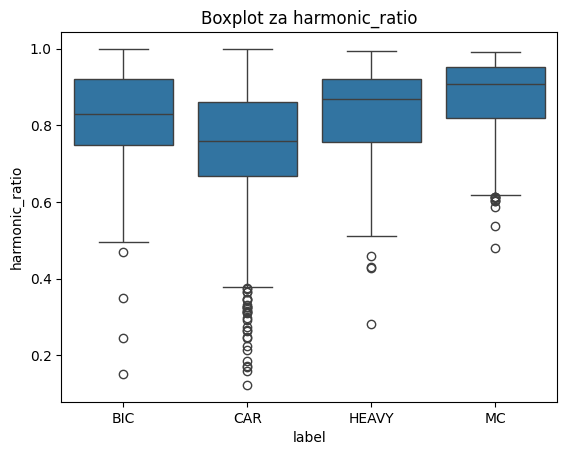

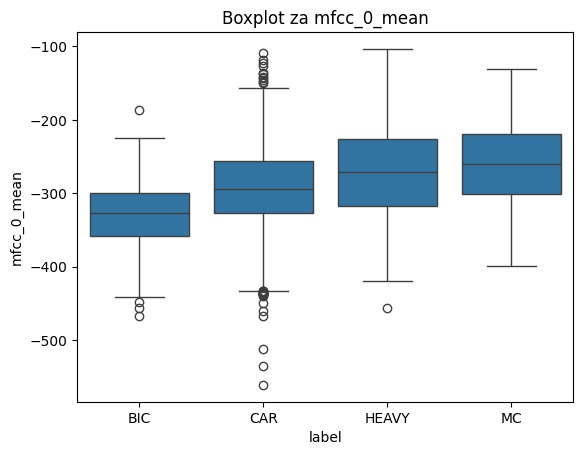

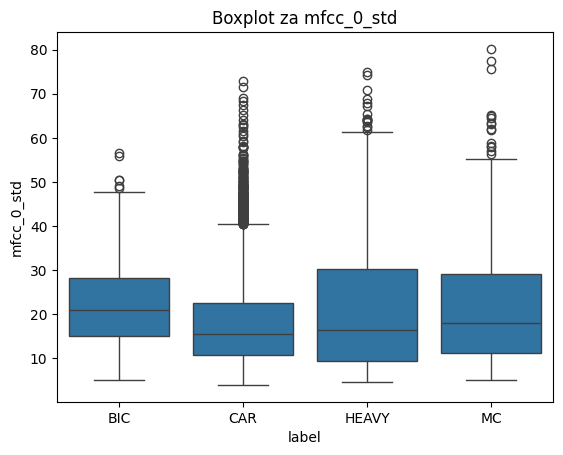

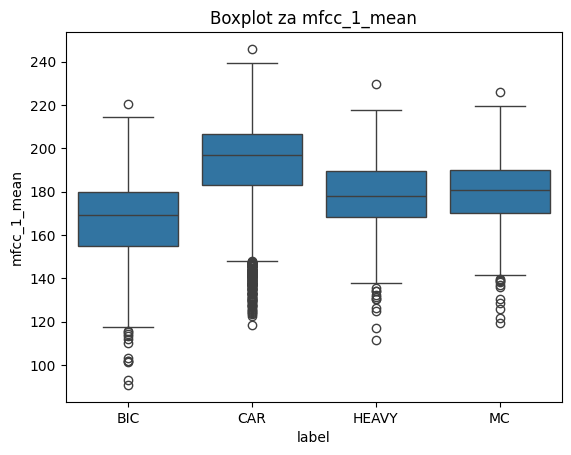

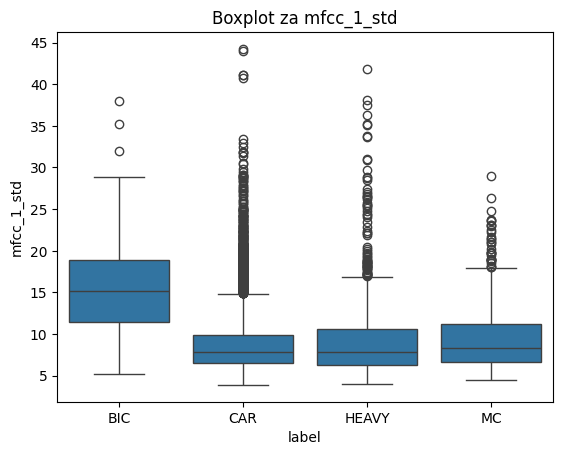

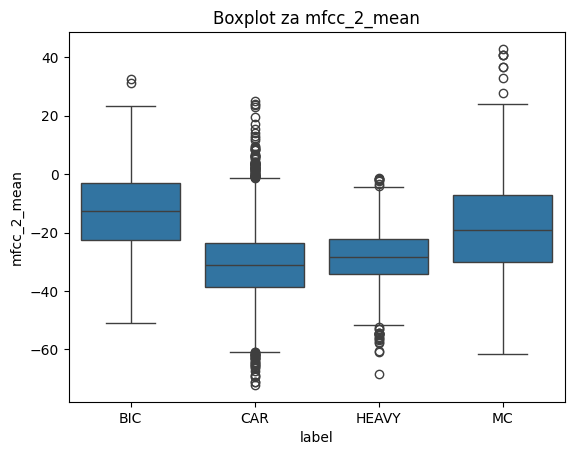

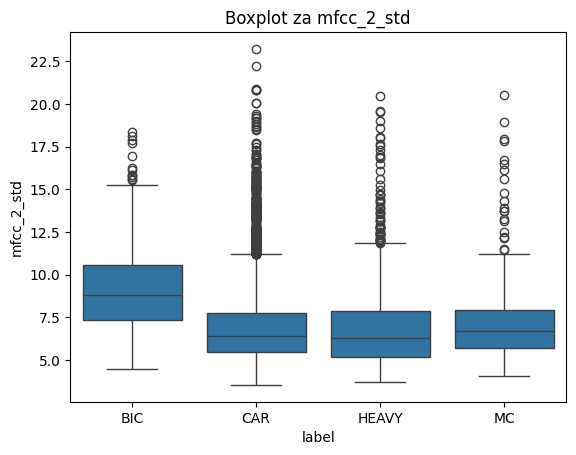

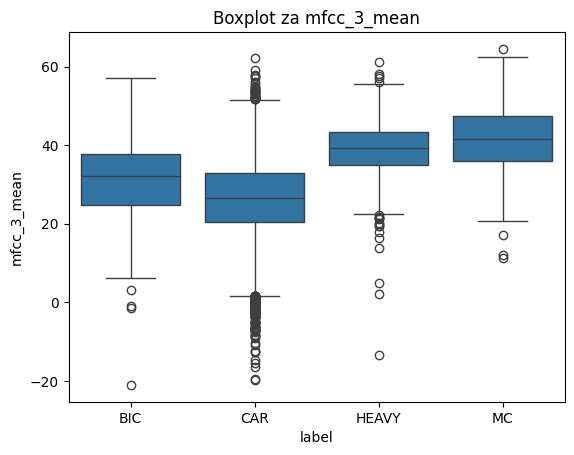

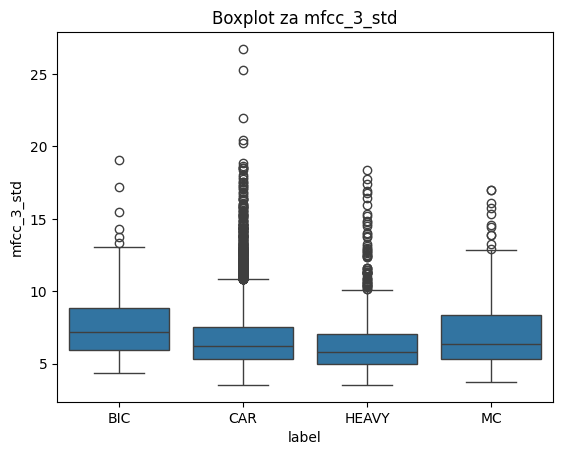

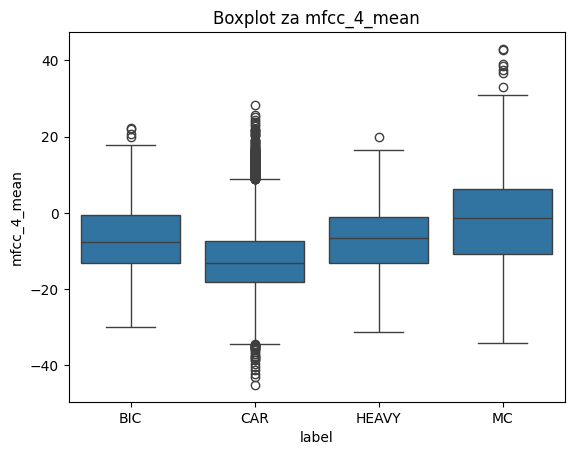

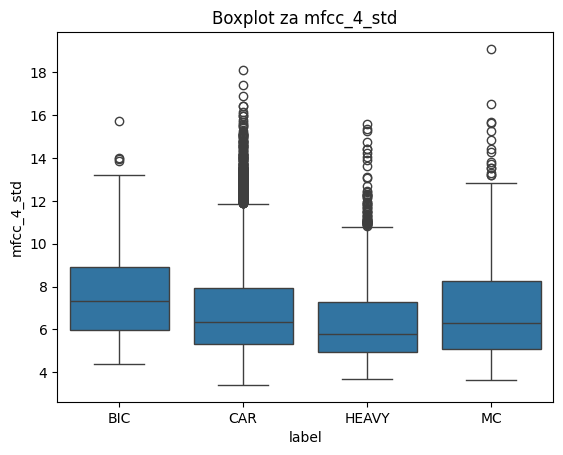

rms                                                              \
        count      mean       std       min       25%       50%       75%   
label                                                                       
BIC     334.0  0.030217  0.019678  0.003069  0.017631  0.025693  0.038509   
CAR    9348.0  0.042082  0.025943  0.001685  0.024239  0.035349  0.054302   
HEAVY  1190.0  0.052054  0.030975  0.006521  0.029151  0.043740  0.066418   
MC      519.0  0.079333  0.052794  0.006183  0.039642  0.065289  0.103955   

                    zcr            ... mfcc_4_mean            mfcc_4_std  \
            max   count      mean  ...         75%        max      count   
label                              ...                                     
BIC    0.143013   334.0  0.038141  ...   -0.646015  22.394442      334.0   
CAR    0.337740  9348.0  0.033406  ...   -7.326954  28.423391     9348.0   
HEAVY  0.253266  1190.0  0.037466  ...   -0.958680  20.009018     1190.0   
MC     0.239141   519.0  0.027216  ...    6.394451  43.008131      519.0   

                                                                              
           mean       std       min       25%       50%       75%        max  
label                                                                         
BIC    7.634948  2.079728  4.400293  5.970074  7.344918  8.933103  15.727910  
CAR    6.875397  2.084258  3.410609  5.308322  6.360060  7.934921  18.089645  
HEAVY  6.412114  2.002375  3.685563  4.956939  5.791231  7.290858  15.600626  
MC     6.965040  2.448926  3.659294  5.081735  6.288259  8.270699  19.088991  

[4 rows x 200 columns]

In [ ]:
# Sto boxplot prikazuje? - medijan, raspon, outliere i distribuciju znacajki po klasama.
# Sto zelimo vidjeti? - zelimo da su medijani i rasponi znacajki po klasama sto razlicitiji, sto znaci da znacajka dobro razlikuje klase.
# zelimo da su kutijice (ove plave) sto uzet i da nam nema mnogo outliera (ovih kruzica vani)

for col in features:
    plt.figure()
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f'Boxplot za {col}')
    plt.show()

df.groupby('label')[features].describe()

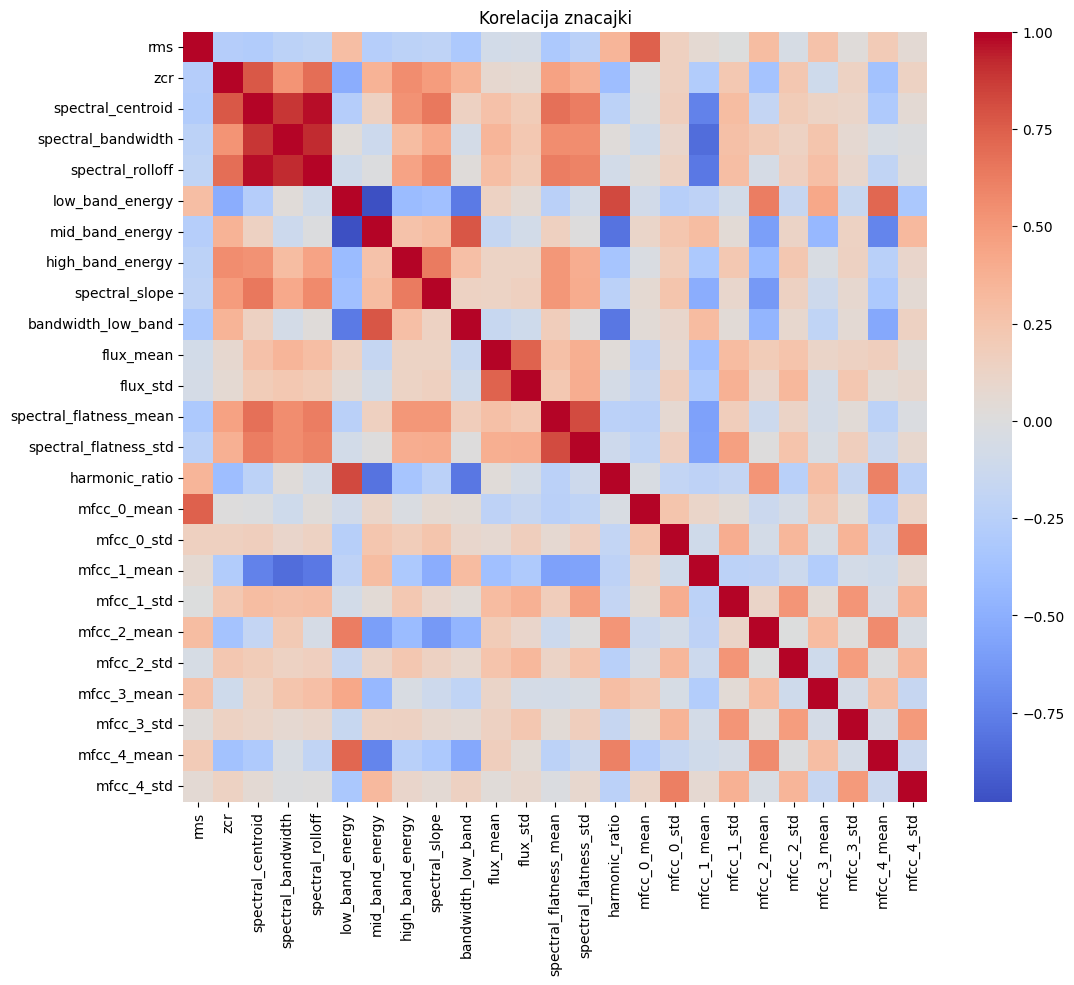

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[features].corr(), cmap='coolwarm', center=0)
plt.title('Korelacija znacajki')
plt.show()

# Sto prikazuje graf? - prikazuje nam korelaciju izmedju znacajki.
# Sto zelimo vidjeti? - zelimo da su korelacije izmedju znacajki sto manje, sto znaci da znacajke nisu redundantne i da svaka znacajka doprinosi razdvajanju klasa.
# Sto ne zelimo vidjeti? - ne zelimo da su korelacije izmedju znacajki velike, to znaci da jednu od njih mozemo izbaciti jer ne doprinosi razdvajanju klasa, a samo usporava model i smanjuje točnost.

In [21]:
# Sto nam pokazuje tablica? - pokazuje nam koliko su znacajke bitne za razdvajanje klasa.
# Sto zelimo vidjeti? - zelimo da su F_score i mutual_info sto veci i p-value sto manji, sto znaci da znacajka dobro razlikuje klase.
# Sto ne zelimo vidjeti? - ne zelimo da su F_score i mutual_info mali i p-value velik, to znaci da znacajka ne razlikuje klase.
# F_score - koliko se klase razlikuju po tom featuru (cilj sto veci imati)
# p_value - koliko je F-score statisticki popuzdan tj. kolika je sansa da se ova razlika (u f-scoreu) dogodila slucajno - cilj sto manji

X = df.drop(columns=['label'])
y = df['label']

F, p = f_classif(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'F_score': F,
    'p_value': p,
}).sort_values(by='F_score', ascending=False)

importance_df

,feature,F_score,p_value
21,mfcc_3_mean,945.122277,0.000000e+00
17,mfcc_1_mean,623.614368,0.000000e+00
3,spectral_bandwidth,600.778547,0.000000e+00
13,spectral_flatness_std,540.191420,0.000000e+00
4,spectral_rolloff,514.515134,1.394938e-313
19,mfcc_2_mean,435.034919,1.362085e-267
18,mfcc_1_std,359.964992,2.322562e-223
0,rms,345.837705,6.001672e-215
23,mfcc_4_mean,345.148594,1.546460e-214
10,flux_mean,334.005390,7.012269e-208


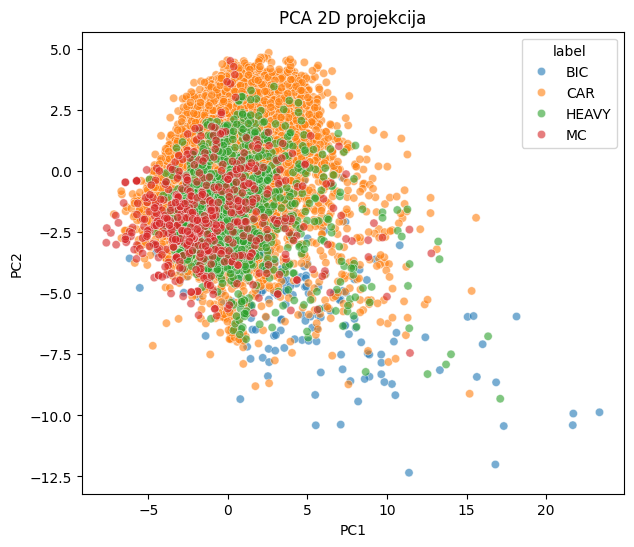

[0.28211714 0.20151061]


In [22]:
# Sto nam graf prikazuje? - prikazuje nam kako su uzorci raspoređeni u prostoru 2D PCA (PCA - Principal Component Analysis)
# Sto zelimo vidjeti? - zelimo da su uzorci po klasama dobro razdvojeni u ovom prostoru.
# Sto ne zelimo vidjeti? - ne zelimo da se uzorci po klasama preklapaju

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = y.values

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', alpha=0.6)
plt.title('PCA 2D projekcija')
plt.show()

# vidimo koliko se informacije gubi (vise od pola) jer PCA standardizira podatke (njih oko 20)
# nadje smjer u prostoru gdje je najveca varijanca i nadje drugi smjer okomit na prvi  i samo 
# projicira 20 dimenzija na 2 zato se toliko informacija gubi
print(pca.explained_variance_ratio_)

# PCA ocito je uzasan, to znaci da problem nije linearno separabilan u ovom prostoru, 
# sto je ocekivano za audio signale. Ali Random Forest dolje je nelinearan model 
# i moze se nositi s ovakvim problemima... pokusaj modela dole



## 4. Usporedba random odabranih spektrograma po klasi

Vizualna provjera "izgleda li" prosjecni spektar svake klase razlicito - dobra dopuna
numerickim znacajkama, jer pokazuje CIJELI vremensko-frekvencijski oblik, ne samo par brojeva.

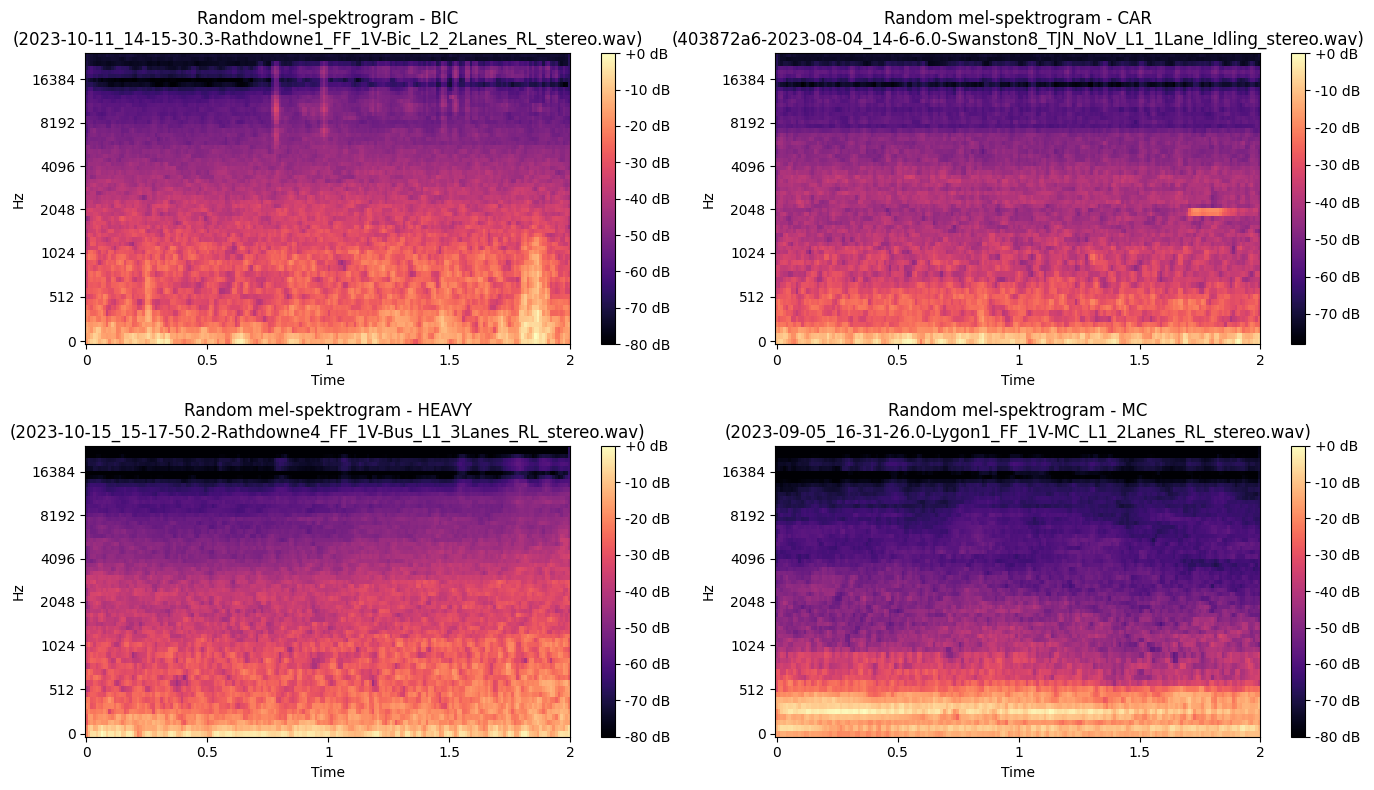

In [23]:
import random

def random_log_mel_spectrogram(base_path, label, sr=48000, seconds=2):
    folder = os.path.join(base_path, label)
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]

    # odaberi random file
    file = random.choice(files)
    path = os.path.join(folder, file)

    y, _ = librosa.load(path, sr=sr)
    y = y[:sr * seconds]
    y = preprocess(y, sr)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db, sr, file

# plotanje
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, label in zip(axes.flat, classes):
    spec, sr, fname = random_log_mel_spectrogram(base_path, label)

    img = librosa.display.specshow(
        spec, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap='magma'
    )

    ax.set_title(f'Random mel-spektrogram - {label}\n({fname})')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()

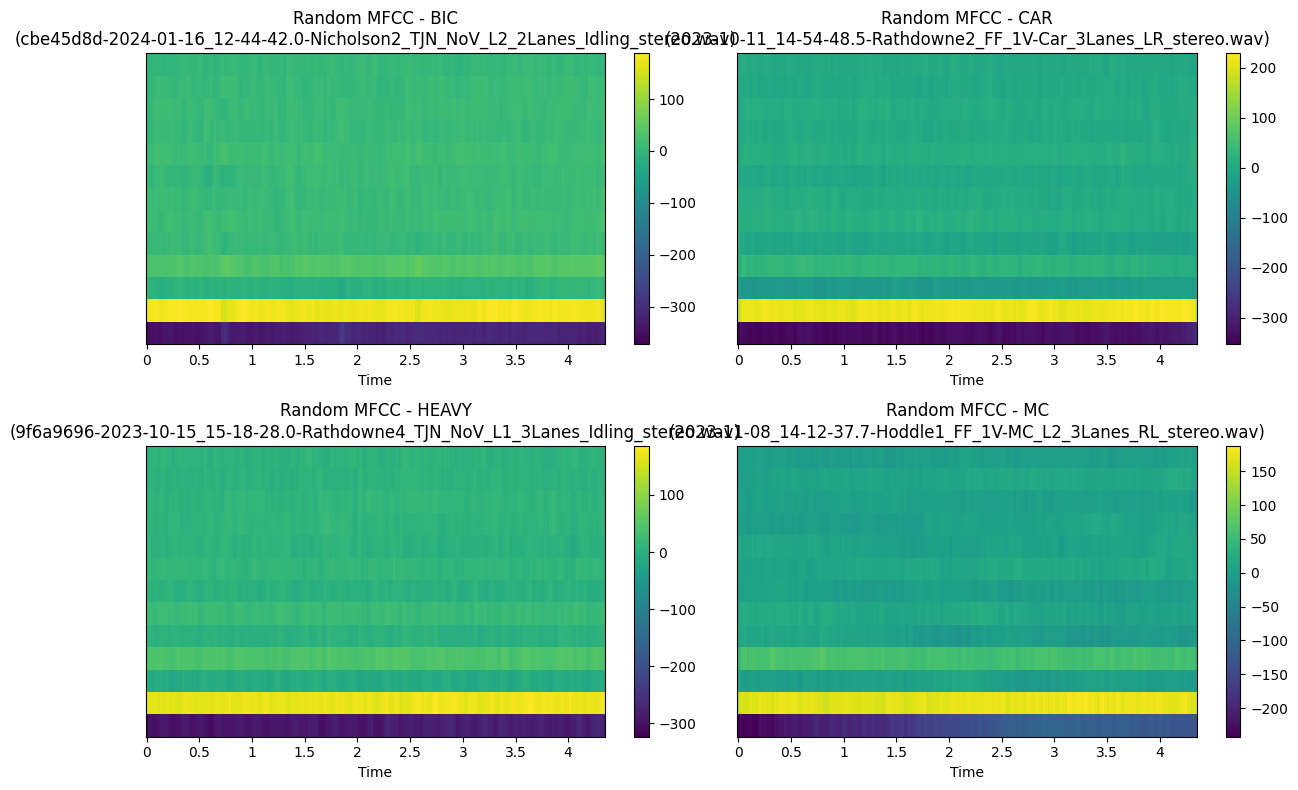

In [24]:
import random

def random_mfcc_per_class(base_path, label, sr=48000, seconds=2):
    folder = os.path.join(base_path, label)
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]

    # random odabir
    file = random.choice(files)
    path = os.path.join(folder, file)

    y, sr = librosa.load(path, sr=sr)
    y = y[:sr * seconds]
    y = preprocess(y, sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    return mfcc, sr, file

#plotanje
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, label in zip(axes.flat, classes):
    mfcc, sr, fname = random_mfcc_per_class(base_path, label)

    img = librosa.display.specshow(
        mfcc, x_axis='time', ax=ax, cmap='viridis'
    )

    ax.set_title(f"Random MFCC - {label}\n({fname})")
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.show()

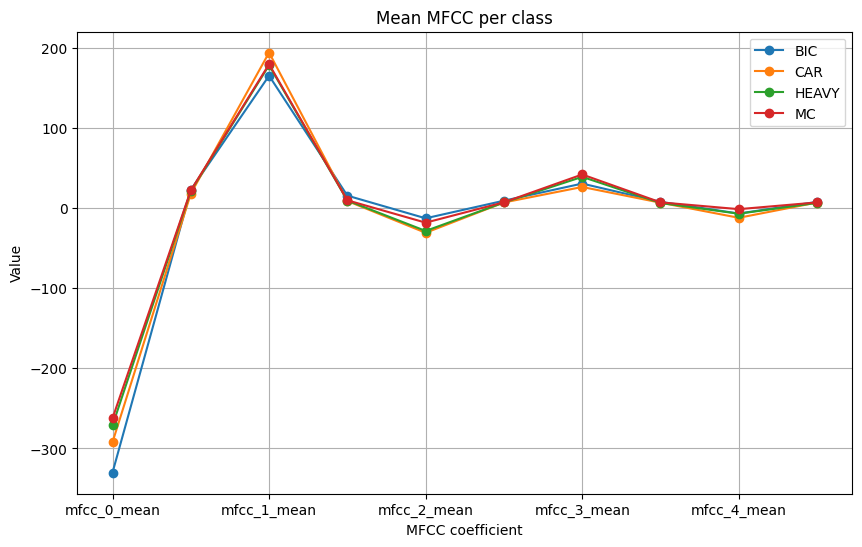

In [25]:
def plot_mean_mfcc_per_class(df):
    mfcc_cols = [col for col in df.columns if 'mfcc' in col]
    
    mean_mfcc = df.groupby('label')[mfcc_cols].mean()
    
    mean_mfcc.T.plot(figsize=(10,6), marker='o')
    plt.title("Mean MFCC per class")
    plt.xlabel("MFCC coefficient")
    plt.ylabel("Value")
    plt.grid()
    plt.legend()
    plt.show()

plot_mean_mfcc_per_class(df)

## 5. Multivarijatni klasifikator - stvarni test

F-test i mutual information analiziraju svaku značajku pojedinačno, tj. mjere koliko je svaka od njih informativna sama za sebe. Međutim, u stvarnom problemu klasifikacije zvuka ključna je kombinacija značajki, jer se razlike između klasa često pojavljuju tek kroz njihove međusobne odnose. Zato koristimo multivarijatni klasifikator, konkretno model Random Forest.

Random Forest je ansambl metoda koja se sastoji od velikog broja stabala odlučivanja (decision trees). Svako stablo:
- trenira se na nasumičnom podskupu podataka
- koristi nasumični podskup značajki

Na kraju, model donosi odluku putem glasanja svih stabala.

Prednosti za naš problem:
- hvata nelinearne odnose između značajki (što smo vidjeli da je ključno)
- robustan je na šum i outliere
- ne zahtijeva stroge pretpostavke o distribuciji podataka
- daje feature importance (što smo već analizirali)

Važno je da model:
- dobro generalizira na neviđene podatke
- ne favorizira dominantnu klasu (CAR)

Zato koristimo:
- class_weight='balanced': penalizira neravnotežu klasa
- stratify pri podjeli: osigurava da sve klase budu proporcionalno zastupljene u train/test skupu

              precision    recall  f1-score   support

         BIC       0.83      0.42      0.56        83
         CAR       0.87      0.98      0.93      2337
       HEAVY       0.76      0.35      0.48       298
          MC       0.78      0.25      0.37       130

    accuracy                           0.87      2848
   macro avg       0.81      0.50      0.59      2848
weighted avg       0.86      0.87      0.84      2848



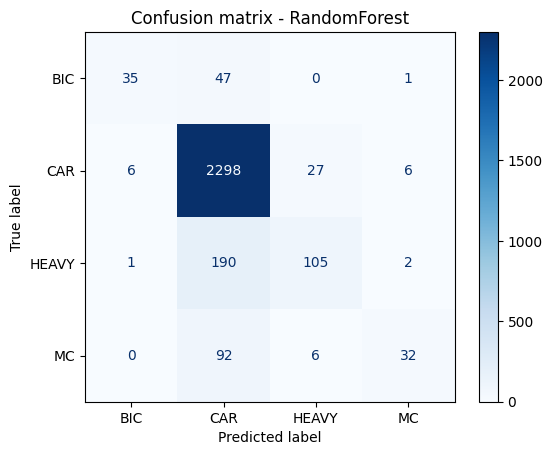

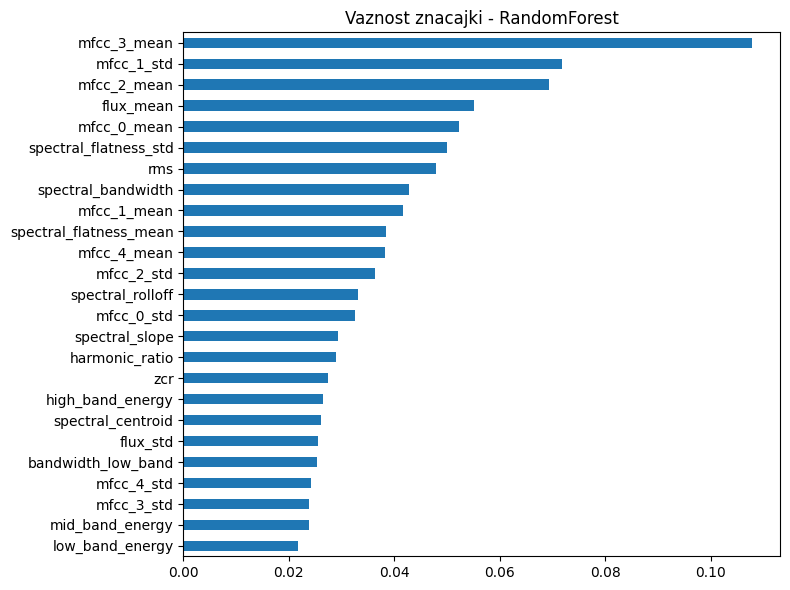

In [ ]:
# Sto nam graf i tablica prikazuju? - prikazuju precision, recall, f1-score i support po klasama, te ukupnu točnost modela.
# precision - koliko je predikcija za klasu točna (koliko je od svih predikcija za tu klasu stvarno pripadalo toj klasi)
# recall - koliko je model dobro prepoznao sve instance klase (koliko je od svih stvarnih instanci klase model ispravno klasificirao)
# F1-score - harmonijska sredina precision i recall, daje balansiranu mjeru točnosti modela po klasi
# support - broj stvarnih instanci klase u testnom skupu
# accuracy - ukupna točnost modela (koliko je od svih instanci model ispravno klasificirao)
# macro avg - prosjek precision, recall i F1-score po klasama, bez uzimanja u obzir koliko instanci svaka klasa ima
# weighted avg - prosjek precision, recall i F1-score po klasama, uzimajući u obzir koliko instanci svaka klasa ima

# Sto zelimo vidjeti? - zelimo da su precision, recall i F1-score po klasama sto veci, sto znaci da model dobro razlikuje klase.
# takodjer zelimo da su accuracy, macro avg i weighted avg sto veci, sto znaci da model dobro razlikuje klase.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, ra
                                                    
                                                    x,asl
clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - RandomForest')
plt.show()

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Vaznost znacajki - RandomForest')
plt.tight_layout()
plt.show()

### Koji bi jos modeli dolazili u obzir?

- SVM: dobar za kompleksne granice izmedju klasa, RBF kernel?
- XGBoost? -    cesto daje bolje rezultate od RandomForesta, jace modelira kompleksne obrasce (gradient boost stable) - cat boost, xg boost...
- Neuronske mreze - RNN, CNN...dobre u koristenju spektograma